# Flow rates

https://alog.ligo-la.caltech.edu/TNT/index.php?callRep=11624



In [2]:
import matplotlib.pyplot as plt
import numpy as np 

axis_font_size = 11.5
figure_size = (6,3.5)

flow_rate = np.array([2.05,1.00,0.75,0.45])
diode_box_T = np.array([22.3,24.8,27.0,31.6])
amp_T = np.array([22.6,24.7,26.8,31.2])
power = np.array([132.9,132.6,132.0,130.1])
HOM = np.array([4.6,4.5,4.8,5.7])
HOM_power = power*(0.01*HOM)
TM00_power = power-HOM_power

[ 126.7866  126.633   125.664   122.6843]


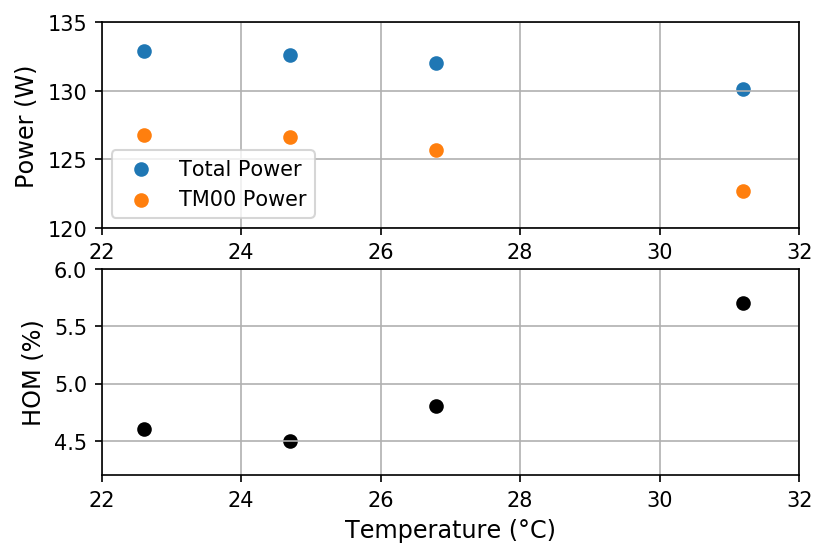

In [3]:
print(TM00_power)
plt.figure(figsize = (6,4),dpi = 150)
plt.subplot(211)
plt.scatter(amp_T,power,label = 'Total Power')
plt.scatter(amp_T,TM00_power, label = 'TM00 Power')
plt.xlim([22,32])
#plt.xlim([0.4,2.1])
plt.ylim([120,135])
plt.grid()
#plt.xlabel(r'Flow rate ($\rm L\,min^{-1}$)',fontsize = axis_font_size)
plt.ylabel('Power (W)',fontsize = axis_font_size)
plt.legend()
plt.subplot(212)
plt.scatter(amp_T,HOM,color ='k')
#plt.xlabel(r'Flow rate ($\rm L\,min^{-1}$)',fontsize = axis_font_size)
plt.xlabel(r'Temperature (°C)',fontsize = axis_font_size)
plt.ylabel('HOM (%)',fontsize = axis_font_size)
plt.xlim([22,32])
#plt.xlim([0.4,2.1])
plt.ylim([4.2,6])
plt.grid()
plt.savefig('ligo_laser_chapter_cooling_pwoer_hom.eps')
plt.show()


# HOM, Power and Currents

# RIN requirement

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


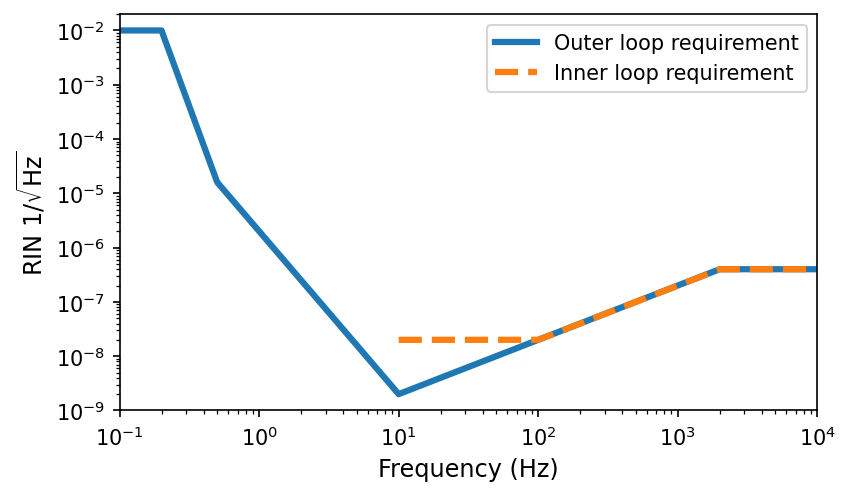

In [4]:
frequency = np.logspace(-1,5,1000)
outer_loop_requirement = np.zeros(len(frequency));

inner_loop_f = np.logspace(1,5,1000);
inner_loop_requirement = np.zeros(len(inner_loop_f));

for idx,f in enumerate(frequency):
    if(f < 2e-1):
        outer_loop_requirement[idx] = 1e-2
    elif( f >= 2e-1 and f < 5e-1):
        outer_loop_requirement[idx] = np.power(f,-7)*1.25e-7
    elif( f >=5e-1 and f < 10):
        outer_loop_requirement[idx] = np.power(f,-3)*2e-6
    elif( f >= 10 and f < 2e3):
        outer_loop_requirement[idx] = f*2e-10
    else:
        outer_loop_requirement[idx] = 4e-7
        
        
for idx,f in enumerate(inner_loop_f):
    if(f<100):
        inner_loop_requirement[idx] =  2e-8
    elif( f >= 100 and f < 2e3):
        inner_loop_requirement[idx] = f*2e-10
    else:
        inner_loop_requirement[idx] = 4e-7
        
plt.figure(figsize = (6,3.5),dpi = 150)
plt.loglog(frequency,outer_loop_requirement,linewidth = 3,label='Outer loop requirement')
plt.loglog(inner_loop_f,inner_loop_requirement,linewidth = 3,linestyle = '--',label='Inner loop requirement')
plt.xlim(0.1,1e4)
plt.ylim(1e-9,2e-2)
plt.xlabel('Frequency (Hz)',fontsize = axis_font_size)
plt.ylabel(r'RIN $1/\sqrt{\rm{Hz}}$',fontsize = axis_font_size)
plt.legend()
plt.savefig('ligo_laser_chapter_iss_requirement.eps')
plt.show()
